# Handling Mixed Variables  Feature Engineering

In [1]:
import pandas as pd
import numpy as np

In [2]:
df_input = pd.read_csv('titanic.csv')
df_input.head()

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


In [3]:
df_input['number'].unique()

<ArrowStringArray>
['5', '3', '6', 'A', '2', '1', '4']
Length: 7, dtype: str

<Axes: xlabel='number'>

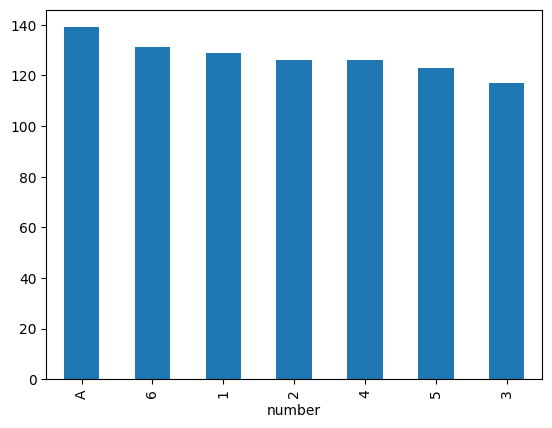

In [4]:
df_input['number'].value_counts().plot(kind='bar')

In [5]:
# extract numerical part
df_input['number_numerical'] = pd.to_numeric(df_input['number'], errors='coerce', downcast='integer')

In [6]:
# extract categorical part
df_input['number_categorical'] = np.where(df_input['number_numerical'].isnull(), df_input['number'], np.nan)

In [7]:
df_input.head()

,Cabin,Ticket,number,Survived,number_numerical,number_categorical
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A


In [8]:
df_input['Cabin'].unique()

<ArrowStringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

In [10]:
df_input['cabin_num'] = df_input['Cabin'].str.extract(r'(\d+)')  # # captures numerical part
df_input['cabin_cat'] = df_input['Cabin'].str[0] # captures the first letter

In [11]:
df_input.head()

,Cabin,Ticket,number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,A,NaN,NaN


<Axes: xlabel='cabin_cat'>

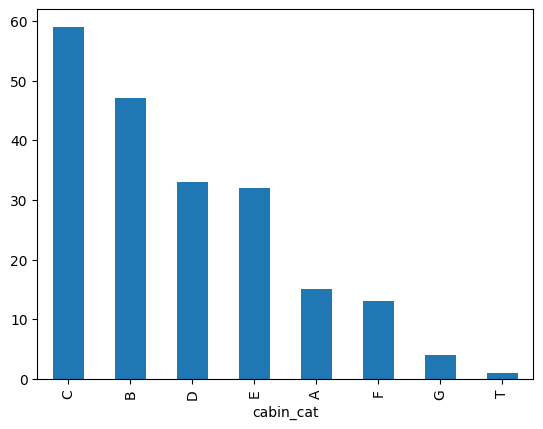

In [12]:
df_input['cabin_cat'].value_counts().plot(kind='bar')